In [ ]:
# Original function for calculating overlap
def is_overlapping(p, mu, pooled_cov):
    chi_square_val = np.sqrt(chi2.ppf(p, df=2))
    pairs = itertools.combinations(range(len(mu)), 2)
    for i, j in pairs:
        diff = mu[i] - mu[j]
        dist = np.linalg.norm(diff)
        radius = chi_square_val * np.sqrt(np.trace(pooled_cov) / 2)
        if dist <= (2 * radius):
            return True
    return False

In [ ]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import chi2

def parse_list(s):
    """Parst einen String wie '[1.0, 2.0, ...]' in ein numpy-Array."""
    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except:
        return np.array([], dtype=float)

def compute_overlap_jsl_style(row, p=0.5):
    """
    Berechnet die Überlappung analog zur JSL-Funktion:
      - Radius A = chi_val * std(distances A zum Zentrum)
      - Radius B = chi_val * std(distances B zum Zentrum)
      - Überlappung, wenn Abstand Zentren <= RadiusA + RadiusB
    """
    # 1) Punkte einlesen
    xa = parse_list(row['coords_a_x'])
    ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x'])
    yb = parse_list(row['coords_b_y'])
    # 2) Validität prüfen
    if len(xa) < 2 or len(xb) < 2 or len(xa)!=len(ya) or len(xb)!=len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    # 3) Zentren berechnen
    mu_a = pts_a.mean(axis=0)
    mu_b = pts_b.mean(axis=0)
    # 4) Abstände der Punkte zu ihrem Zentrum
    dist_a = np.linalg.norm(pts_a - mu_a, axis=1)
    dist_b = np.linalg.norm(pts_b - mu_b, axis=1)
    # 5) Standardabweichungen dieser Abstände (entspricht stdMat in JSL)
    std_a = dist_a.std(ddof=1)
    std_b = dist_b.std(ddof=1)
    # 6) Chi-Quadrat-Faktor
    chi_val = np.sqrt(chi2.ppf(p, df=2))
    # 7) Radien
    r1 = chi_val * std_a
    r2 = chi_val * std_b
    # 8) Abstand der Zentren
    center_dist = np.linalg.norm(mu_a - mu_b)
    # 9) Überlappungstest
    return center_dist <= (r1 + r2)

def main():
    # Pfade anpassen
    input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\eurasian_otter_all_results_combined.csv'
    output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\otter_results_with_ellipse_overlap2.csv'
    

    # 1) DataFrame einlesen (Strings behalten)
    df = pd.read_csv(input_csv, dtype=str)

    # 2) Neue Spalte berechnen
    df['ellipse_overlap'] = df.apply(compute_overlap_jsl_style, axis=1)

    # 3) Speichern
    df.to_csv(output_csv, index=False)
    print(f"Fertig! Ergebnisse mit Spalte 'ellipse_overlap' liegen in '{output_csv}'.")

if __name__ == '__main__':
    main()


In [ ]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import chi2
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# 1) Pfade anpassen
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\eurasian_otter_all_results_combined.csv'
output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'

# 2) Daten einlesen
df = pd.read_csv(input_csv, dtype=str)

# 3) Parser für Listen-Strings
def parse_list(s):
    if not isinstance(s, str) or not s.strip() or s.strip().lower() == 'nan':
        return np.empty(0, float)
    s2 = s.strip().strip('"').strip("'").strip('[]')
    try:
        lst = ast.literal_eval(f"[{s2}]")
        return np.array(lst, dtype=float)
    except:
        try:
            return np.fromstring(s2, sep=' ')
        except:
            return np.empty(0, float)

# 4) Exakte JMP-Overlap-Funktion (kreisförmig, stdMat[,1])
def compute_overlap_exact(row_idx):
    row = df.iloc[row_idx]
    xa = parse_list(row['coords_a_x']); ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x']); yb = parse_list(row['coords_b_y'])
    if len(xa) < 2 or len(xb) < 2 or len(xa) != len(ya) or len(xb) != len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a = pts_a.mean(axis=0)
    mu_b = pts_b.mean(axis=0)
    cov_a = np.cov(pts_a, rowvar=False)
    cov_b = np.cov(pts_b, rowvar=False)
    # größte Eigenwerte
    lambda1_a = max(np.linalg.eigvalsh(cov_a))
    lambda1_b = max(np.linalg.eigvalsh(cov_b))
    # Radius
    chi_val = np.sqrt(chi2.ppf(0.5, df=2))
    r_a = chi_val * np.sqrt(lambda1_a)
    r_b = chi_val * np.sqrt(lambda1_b)
    center_dist = np.linalg.norm(mu_a - mu_b)
    return center_dist <= (r_a + r_b)

# 5) Parallel berechnen
n_jobs = -1  # alle Kerne nutzen
results = Parallel(n_jobs=n_jobs, prefer="threads")(
    delayed(compute_overlap_exact)(i) for i in range(len(df))
)

df['ellipse_overlap'] = results

# 6) Beispielplots (optional, kann sequentiell laufen)
sample_idxs = df[df['ellipse_overlap'].notna()].sample(3, random_state=42).index
for idx in sample_idxs:
    row = df.loc[idx]
    xa = parse_list(row['coords_a_x']); ya = parse_list(row['coords_a_y'])
    xb = parse_list(row['coords_b_x']); yb = parse_list(row['coords_b_y'])
    pts_a = np.column_stack([xa, ya]); pts_b = np.column_stack([xb, yb])
    mu_a = pts_a.mean(axis=0); mu_b = pts_b.mean(axis=0)
    cov_a = np.cov(pts_a, rowvar=False); cov_b = np.cov(pts_b, rowvar=False)
    lambda1_a = max(np.linalg.eigvalsh(cov_a)); lambda1_b = max(np.linalg.eigvalsh(cov_b))
    chi_val = np.sqrt(chi2.ppf(0.5, df=2))
    r_a = chi_val * np.sqrt(lambda1_a); r_b = chi_val * np.sqrt(lambda1_b)

    fig, ax = plt.subplots()
    ax.scatter(pts_a[:,0], pts_a[:,1], label='A')
    ax.scatter(pts_b[:,0], pts_b[:,1], label='B')
    ax.add_patch(Ellipse(mu_a, 2*r_a, 2*r_a, edgecolor='blue', facecolor='none'))
    ax.add_patch(Ellipse(mu_b, 2*r_b, 2*r_b, edgecolor='red', facecolor='none'))
    ax.set_aspect('equal'); ax.legend()
    ax.set_title(f'Index {idx} – Overlap: {row["ellipse_overlap"]}')
    plt.show()

# 7) Speichern
df.to_csv(output_csv, index=False)
print(f"Ergebnis gespeichert in: {output_csv}")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Daten laden ---
output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'
df = pd.read_csv(output_csv, dtype=str)

# Ziel und Vorhersage in numerisch
df['same_individual']  = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['ellipse_overlap']  = df['ellipse_overlap'].map({'True':1,'False':0,'0':0,'1':1}).astype(int)

# --- 2) Kennzahlen pro Pipeline berechnen ---
pipelines = df['pipeline'].unique()
metrics = []
for p in pipelines:
    sub    = df[df['pipeline']==p]
    y_true = sub['same_individual']
    y_pred = sub['ellipse_overlap']
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr  = recall_score(y_true, y_pred)
    tnr  = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    acc  = accuracy_score(y_true, y_pred)
    bal  = (tpr + tnr) / 2
    hm   = 2 * (tpr * tnr) / (tpr + tnr) if (tpr + tnr) > 0 else np.nan
    metrics.append({
        'pipeline': p,
        'tpr': tpr,
        'tnr': tnr,
        'accuracy': acc,
        'balanced_accuracy': bal,
        'harmonic_mean': hm
    })
metrics_df = pd.DataFrame(metrics)

# --- 3) Bar-Plots für HM, BA und Overall Accuracy ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    x='harmonic_mean', y='pipeline',
    data=metrics_df.sort_values('harmonic_mean', ascending=False),
    ax=axes[0]
)
axes[0].set_title("Harmonisches Mittel (HM)")

sns.barplot(
    x='balanced_accuracy', y='pipeline',
    data=metrics_df.sort_values('balanced_accuracy', ascending=False),
    ax=axes[1]
)
axes[1].set_title("Balanced Accuracy")

sns.barplot(
    x='accuracy', y='pipeline',
    data=metrics_df.sort_values('accuracy', ascending=False),
    ax=axes[2]
)
axes[2].set_title("Overall Accuracy")

# gemeinsame Legende:
for ax in axes:
    ax.set_xlabel("")  # Labels optional
axes[0].set_xlabel("HM")
axes[1].set_xlabel("Balanced Acc")
axes[2].set_xlabel("Accuracy")

plt.tight_layout()
plt.show()

# --- 4) Top-Pipelines auswählen & Confusion-Matrices plotten ---
best_hm  = metrics_df.loc[metrics_df['harmonic_mean'].idxmax(), 'pipeline']
best_bal = metrics_df.loc[metrics_df['balanced_accuracy'].idxmax(), 'pipeline']
best_acc = metrics_df.loc[metrics_df['accuracy'].idxmax(),        'pipeline']
best_unique = list(dict.fromkeys([best_hm, best_bal, best_acc]))

fig, axes = plt.subplots(1, len(best_unique), figsize=(6*len(best_unique), 5))
if len(best_unique) == 1:
    axes = [axes]

for ax, p in zip(axes, best_unique):
    sub = df[df['pipeline'] == p]
    cm = confusion_matrix(sub['same_individual'], sub['ellipse_overlap'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1']
    )
    m = metrics_df[metrics_df['pipeline'] == p].iloc[0]
    ax.set_title(
        f'{p}\nTPR={m.tpr:.2f}, TNR={m.tnr:.2f}\n'
        f'BA={m.balanced_accuracy:.2f}, ACC={m.accuracy:.2f}'
    )

# Legende für alle CMs (einfacher Platzhalter)
plt.tight_layout()
plt.show()

# --- 5) Fehler-Typ markieren und Observations numeric ---
df['error_type'] = np.where(
    (df['same_individual']==0) & (df['ellipse_overlap']==1), 'FP',
    np.where((df['same_individual']==1) & (df['ellipse_overlap']==0), 'FN', 'OK')
)
df['min_observations'] = df['min_observations'].astype(float).round().astype(int)
df['max_observations'] = df['max_observations'].astype(float).round().astype(int)
df['obs_range']        = (df['max_observations'] - df['min_observations']).astype(int)

errors_all  = df[df['error_type'].isin(['FP','FN'])]
errors_best = errors_all[errors_all['pipeline'].isin(best_unique)]

# --- 6) Kombinierter Stacked-Bar-Plot für alle und Top-Modelle ---
def plot_combined(errors, title, colors):
    # counts per metric & x
    counts = {}
    for metric in ['min_observations','max_observations','obs_range']:
        ct = errors.groupby([metric,'error_type']).size().unstack(fill_value=0)
        ct = ct.reindex(range(0,10), fill_value=0)
        counts[metric] = ct

    labels = {'min_observations':'Min Obs','max_observations':'Max Obs','obs_range':'Range'}
    x = np.arange(0, 10)
    total_width = 0.8
    n_metrics   = 3
    width       = total_width / n_metrics
    offsets     = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, n_metrics)

    plt.figure(figsize=(12,6))
    for i, metric in enumerate(['min_observations','max_observations','obs_range']):
        ct   = counts[metric]
        xpos = x + offsets[i]
        bottom = np.zeros_like(x, dtype=int)
        for et in ['FP','FN']:
            plt.bar(
                xpos, ct.get(et, 0), width=width, bottom=bottom,
                color=colors[metric][et],
                label=f"{labels[metric]} {et}" if i == 0 else ""
            )
            bottom += ct.get(et, 0).values

    plt.xticks(x, x)
    plt.xlabel("Beobachtungswert (0–9)")
    plt.ylabel("Anzahl Fehler")
    plt.title(title)
    # zusammengeführte Legende
    handles, lbls = plt.gca().get_legend_handles_labels()
    by_lbls = dict(zip(lbls, handles))
    plt.legend(by_lbls.values(), by_lbls.keys(), title="Metrik & Error", bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Palettenvarianten (einfach auskommentieren, was gefällt):
# pal_variant1 = {
#    'min_observations': {'FP':'#ff9999','FN':'#cc0000'},
#    'max_observations': {'FP':'#99ff99','FN':'#009900'},
#    'obs_range':        {'FP':'#9999ff','FN':'#0000cc'}
#}
# pal_variant2 = {
#    'min_observations': {'FP':'#fee0d2','FN':'#de2d26'},
#    'max_observations': {'FP':'#c7e9c0','FN':'#238b45'},
#    'obs_range':        {'FP':'#dadaeb','FN':'#3f007d'}
#}
pal_variant3 = {
    'min_observations': {'FP':sns.color_palette("Reds",   2)[0],'FN':sns.color_palette("Reds",   2)[1]},
    'max_observations': {'FP':sns.color_palette("Greens", 2)[0],'FN':sns.color_palette("Greens", 2)[1]},
    'obs_range':        {'FP':sns.color_palette("Blues",  2)[0],'FN':sns.color_palette("Blues",  2)[1]}
}

# Plot für alle Modelle mit gewählter Palette
plot_combined(errors_all,  "Alle Modelle: FP/FN nach Beobachtungswert", pal_variant3)
# Plot für Top-Modelle mit gleicher Palette
plot_combined(errors_best, "Top-Modelle: FP/FN nach Beobachtungswert", pal_variant3)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# 1) Daten laden & vorbereiten
output_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'
df = pd.read_csv(output_csv, dtype=str)

# Ziel und Fold-Typen
df['same_individual'] = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['fold']            = df['fold'].astype(float).astype(int)

# Imputation avg_proba_*
for col in ['avg_proba_A_0','avg_proba_B_0']:
    valid = df[df[col].notna()]
    fill_map = (
        valid
        .groupby('comparison_id')[col]
        .agg(lambda s: s.unique()[0] if len(s.unique())==1 else np.nan)
        .dropna()
        .to_dict()
    )
    df[col] = df.apply(lambda r: fill_map.get(r['comparison_id'], r[col]), axis=1)

# 2) Feature-Engineering
drop_cols = [
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b'
]
X_raw = df.drop(columns=drop_cols)
y     = df['same_individual']
groups= df['fold']

# One-hot-Encoding und Drop konstanter Spalten
X_enc = pd.get_dummies(X_raw, drop_first=True)
const_cols = X_enc.columns[X_enc.nunique() <= 1]
X_enc.drop(columns=const_cols, inplace=True)

# 3) Modell-Pipeline
model_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('select', SelectKBest(f_classif, k=10)),
    ('clf', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
])

# 4) Debug-Evaluationsfunktion
def eval_pipeline(pipe_name):
    mask    = df['pipeline'] == pipe_name
    X_sub   = X_enc.loc[mask]
    y_sub   = y.loc[mask]
    grp_sub = groups.loc[mask]

    gkf = GroupKFold(n_splits=df['fold'].nunique())
    accs, bals, tprs, tnrs = [], [], [], []

    for fold_idx, (tr, te) in enumerate(gkf.split(X_sub, y_sub, groups=grp_sub)):
        y_train = y_sub.iloc[tr]
        y_test  = y_sub.iloc[te]
        # Debug-Print: Klassenverteilung pro Fold
        print(f">>> Pipeline {pipe_name} – Fold {fold_idx}: "
              f"Train classes {y_train.value_counts().to_dict()} | "
              f"Test classes {y_test.value_counts().to_dict()}")
        if y_train.nunique()<2 or y_test.nunique()<2:
            print(f"    Skipping fold {fold_idx} for pipeline {pipe_name} (nur eine Klasse vorhanden)")
            continue

        X_train, X_test = X_sub.iloc[tr], X_sub.iloc[te]
        model_pipe.fit(X_train, y_train)
        y_pred = model_pipe.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        bals.append(balanced_accuracy_score(y_test, y_pred))
        tprs.append(recall_score(y_test, y_pred))
        tn = ((y_test==0)&(y_pred==0)).sum()
        fp = ((y_test==0)&(y_pred==1)).sum()
        tnrs.append(tn/(tn+fp))

    return {
        'pipeline': pipe_name,
        'accuracy_mean':          np.mean(accs) if accs else np.nan,
        'balanced_accuracy_mean': np.mean(bals) if bals else np.nan,
        'tpr_mean':               np.mean(tprs) if tprs else np.nan,
        'tnr_mean':               np.mean(tnrs) if tnrs else np.nan
    }

# 5) Serielles Durchlaufen aller Pipelines
results = []
for p in df['pipeline'].unique():
    try:
        results.append(eval_pipeline(p))
    except Exception as e:
        print(f"!!! Fehler in Pipeline {p}: {e}")
        break

# 6) Ergebnisse anzeigen
results_df = pd.DataFrame(results)
print("\nErgebnisse pro Pipeline:")
print(results_df.sort_values('balanced_accuracy_mean', ascending=False))


>>> Pipeline univariate_clip_standard_k200_pca_nc3_sex_off – Fold 0: Train classes {0: 31, 1: 29} | Test classes {1: 21, 0: 9}


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46767 46768 46769] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


>>> Pipeline univariate_clip_standard_k200_pca_nc3_sex_off – Fold 1: Train classes {1: 35, 0: 25} | Test classes {0: 15, 1: 15}


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46767 46768 46769] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


>>> Pipeline univariate_clip_standard_k200_pca_nc3_sex_off – Fold 2: Train classes {1: 36, 0: 24} | Test classes {0: 16, 1: 14}


...

>>> Pipeline forward_no_out_no_scale_k10_lda_nc2_sex_on – Fold 1: Train classes {1: 35, 0: 25} | Test classes {0: 15, 1: 15}


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46750 46752 46765] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


>>> Pipeline forward_no_out_no_scale_k10_lda_nc2_sex_on – Fold 2: Train classes {1: 36, 0: 24} | Test classes {0: 16, 1: 14}


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46749 46751 46768] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Ergebnisse pro Pipeline:
                                         pipeline  accuracy_mean  \
13     forward_no_out_no_scale_k10_lda_nc2_sex_on       0.855556   
12    forward_no_out_no_scale_k10_lda_nc2_sex_off       0.833333   
8     forward_no_out_no_scale_k14_lda_nc2_sex_off       0.777778   
10    forward_no_out_no_scale_k12_lda_nc2_sex_off       0.788889   
7      forward_no_out_no_scale_k16_lda_nc2_sex_on       0.788889   
5      forward_no_out_no_scale_k18_lda_nc2_sex_on       0.777778   
3      forward_no_out_no_scale_k20_lda_nc2_sex_on       0.777778   
2     forward_no_out_no_scale_k20_lda_nc2_sex_off       0.744444   
11     forward_no_out_no_scale_k12_lda_nc2_sex_on       0.755556   
9      forward_no_out_no_scale_k14_lda_nc2_sex_on       0.755556   
4     forward_no_out_no_scale_k18_lda_nc2_sex_off       0.666667   
6     forward_no_out_no_scale_k16_lda_nc2_sex_off       0.666667   
0   univariate_clip_standard_k200_pca_nc3_sex_off       0.622222   
1     variance_zscore_

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from joblib import dump
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Categorical

# Speicherorte
MODEL_DIR = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\models")
PRED_CSV  = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\predictions_with_ml.csv")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1) Daten laden & sexmodel-Leaks filtern
df = pd.read_csv(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv",
    dtype=str
)
df = df[df['use_sexmodel_prediction']=='False'].copy()

# 2) Ziel & Fold
df['same_individual'] = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['fold']            = df['fold'].astype(float).astype(int)

# 3) Imputation avg_proba_*
for col in ['avg_proba_A_0','avg_proba_B_0']:
    valid = df[df[col].notna()]
    fill  = (valid
             .groupby('comparison_id')[col]
             .agg(lambda s: s.unique()[0] if len(s.unique())==1 else np.nan)
             .dropna()
             .to_dict())
    df[col] = df.apply(lambda r: fill.get(r['comparison_id'], r[col]), axis=1)

# 4) Features vorbereiten
drop_cols = [
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b',
    'use_sexmodel_prediction'
]
X_raw = df.drop(columns=drop_cols)
y     = df['same_individual']
groups= df['fold']

X_enc = pd.get_dummies(X_raw, drop_first=True)
consts = X_enc.columns[X_enc.nunique() <= 1]
X_enc.drop(columns=consts, inplace=True)

# 5) Pipeline‐Template & Suchraum‐Definition
def make_search(cv):
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca', PCA()),
        ('select', SelectKBest(f_classif)),
        ('clf', RandomForestClassifier())
    ])
    search_spaces = {
        'pca': Categorical(['passthrough'] + [PCA(n_components=i) for i in range(1,6)], transform='string'),
        'select__k': Categorical([1,2,3,5,10, X_enc.shape[1]]),
        'clf': Categorical([
            RandomForestClassifier(n_estimators=50,  random_state=42),
            RandomForestClassifier(n_estimators=200, random_state=42),
            ExtraTreesClassifier(n_estimators=100, random_state=42),
            XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
            SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
        ], transform='string')
    }
    return BayesSearchCV(
        estimator=pipe,
        search_spaces=search_spaces,
        scoring=make_scorer(balanced_accuracy_score),
        cv=cv,
        n_iter=100,
        n_jobs=-1,
        refit=True,
        random_state=42,
        verbose=0
    )

# 6) Globales Modell trainieren
global_cv = GroupKFold(n_splits=groups.nunique())
global_search = make_search(global_cv)
global_search.fit(X_enc, y, groups=groups)
print("GLOBAL best BA:", global_search.best_score_)
print("GLOBAL best params:", global_search.best_params_)

# Speichern & Vorhersagen
dump(global_search.best_estimator_, MODEL_DIR/"global_model.joblib")
df['pred_global'] = global_search.predict(X_enc)

# 7) Lokale Modelle je Pipeline
df['pred_local'] = 0
for p in df['pipeline'].unique():
    mask = df['pipeline']==p
    Xp, yp, gp = X_enc[mask], y[mask], groups[mask]
    if len(yp) < 10:
        # zu wenig Daten → Default 0
        df.loc[mask, 'pred_local'] = 0
        continue
    local_cv     = GroupKFold(n_splits=gp.nunique())
    local_search = make_search(local_cv)
    local_search.fit(Xp, yp, groups=gp)
    print(f"{p} best BA:", local_search.best_score_)
    dump(local_search.best_estimator_, MODEL_DIR/f"local_model_{p}.joblib")
    df.loc[mask, 'pred_local'] = local_search.predict(Xp)

# 8) Ergebnisse speichern
df.to_csv(PRED_CSV, index=False)
print("Saved predictions to", PRED_CSV)


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...), np.str_('passthrough'), np.int64(32664)] before, using random

Classification Report (globales Modell):
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       560
           1      1.000     1.000     1.000       700

    accuracy                          1.000      1260
   macro avg      1.000     1.000     1.000      1260
weighted avg      1.000     1.000     1.000      1260



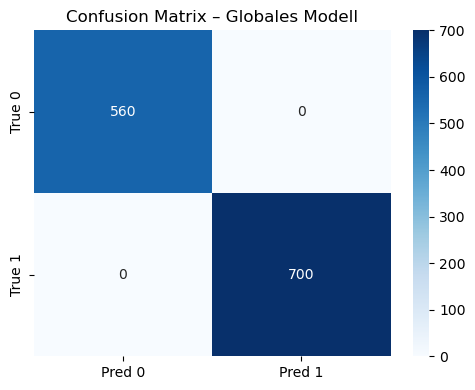

C:\Users\Frede\AppData\Local\Temp\ipykernel_20228\1334660334.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.iloc[:top_n], y=feat_imp.iloc[:top_n].index, palette="viridis")


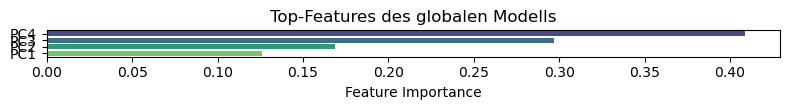

In [3]:
# === Notebook-Block: Zusammenfassung & Feature Importances des globalen Modells ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1) Lade die Daten & Vorhersagen
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv'


df = pd.read_csv(input_csv, dtype=str)
df['same_individual']    = df['same_individual'].map({'True':1,'False':0,'1':1,'0':0})
df['ml_pred_global']     = df['ml_pred_global'].map({'1':1,'0':0}).fillna(0).astype(int)

# 2) Berechne und zeige Kennzahlen des globalen Modells
y_true = df['same_individual']
y_pred = df['ml_pred_global']

print("Classification Report (globales Modell):")
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Confusion Matrix – Globales Modell")
plt.tight_layout()
plt.show()

# 3) Feature Importances extrahieren
#    Wir gehen davon aus, dass 'bayes' aus Deinem vorherigen Block im Scope ist
best_pipe = bayes.best_estimator_

# Hole Namen der Eingangsfeatures vor Encoding
# (die DataFrame X_enc hatten wir per one-hot erstellt)
X_raw = df.drop(columns=[
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b'
])
X_enc = pd.get_dummies(X_raw, drop_first=True)
# Entferne konstante Spalten wie zuvor
consts = X_enc.columns[X_enc.nunique() <= 1]
X_enc.drop(columns=consts, inplace=True)

# Feature-Namen nach PCA
pca_step = best_pipe.named_steps['pca']
if pca_step == 'passthrough' or getattr(pca_step, 'n_components_', None) is None:
    feat_names = X_enc.columns.to_list()
else:
    n_comp = pca_step.n_components_
    feat_names = [f"PC{i+1}" for i in range(n_comp)]

# Maske der ausgewählten Features
select_mask = best_pipe.named_steps['select'].get_support()
selected_feats = [feat_names[i] for i, on in enumerate(select_mask) if on]

# Importances vom Klassifikator
clf = best_pipe.named_steps['clf']
importances = clf.feature_importances_

# Mappe Importances auf die ausgewählten Features
feat_imp = pd.Series(importances, index=selected_feats)
feat_imp = feat_imp.sort_values(ascending=False)

# 4) Plot der Top-20 Features
top_n = min(20, len(feat_imp))
plt.figure(figsize=(8, top_n*0.3))
sns.barplot(x=feat_imp.iloc[:top_n], y=feat_imp.iloc[:top_n].index, palette="viridis")
plt.title("Top-Features des globalen Modells")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


=== Classification Report (globales Modell) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       320
           1      1.000     1.000     1.000       400

    accuracy                          1.000       720
   macro avg      1.000     1.000     1.000       720
weighted avg      1.000     1.000     1.000       720



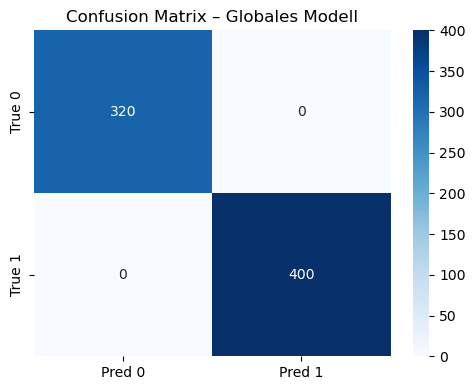

NameError: name 'bayes' is not defined

In [1]:
# === Notebook-Block: Zusammenfassung & Feature Importances des globalen Modells (nur use_sexmodel_prediction == False) ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1) Lade die Daten & Vorhersagen
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv'
df = pd.read_csv(input_csv, dtype=str)

# 2) Filter: nur Zeilen mit use_sexmodel_prediction == False
df = df[df['use_sexmodel_prediction'] == 'False'].copy()

# 3) Droppe alle Sex-Modell-Proba-Spalten (z.B. 'sex_proba_*')
sex_proba_cols = [c for c in df.columns if 'sex' in c.lower() and 'proba' in c.lower()]
df.drop(columns=sex_proba_cols, inplace=True)

# 4) Ziel und Vorhersage numerisch umwandeln
df['same_individual'] = df['same_individual'].map({'True':1,'False':0,'1':1,'0':0}).astype(int)
df['ml_pred_global']  = df['ml_pred_global'].map({'1':1,'0':0}).fillna(0).astype(int)

# 5) Classification Report & Confusion Matrix
y_true = df['same_individual']
y_pred = df['ml_pred_global']

print("=== Classification Report (globales Modell) ===")
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Confusion Matrix – Globales Modell")
plt.tight_layout()
plt.show()

# 6) Feature-Engineering zum Rebuild von X_enc
drop_cols = [
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b',
    'use_sexmodel_prediction'  # ebenfalls dropped
] + sex_proba_cols

X_raw = df.drop(columns=drop_cols)
X_enc = pd.get_dummies(X_raw, drop_first=True)
consts = X_enc.columns[X_enc.nunique() <= 1]
X_enc.drop(columns=consts, inplace=True)

# 7) Feature Importances extrahieren aus best_pipe
#    (bayes.best_estimator_ muss im Scope sein)
best_pipe = bayes.best_estimator_

# 7a) Features nach PCA
pca = best_pipe.named_steps['pca']
if pca == 'passthrough' or getattr(pca, 'n_components_', None) is None:
    feat_names = X_enc.columns.to_list()
else:
    feat_names = [f"PC{i+1}" for i in range(pca.n_components_)]

# 7b) FeatureSelection-Mask
select = best_pipe.named_steps['select']
mask = select.get_support()
selected_feats = [feat_names[i] for i, flag in enumerate(mask) if flag]

# 7c) Importances aus dem Classifier
clf = best_pipe.named_steps['clf']
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=selected_feats).sort_values(ascending=False)

# 8) Plot der Top-20 Features
top_n = min(20, len(feat_imp))
plt.figure(figsize=(8, top_n * 0.3))
sns.barplot(x=feat_imp.iloc[:top_n],
            y=feat_imp.iloc[:top_n].index,
            palette="viridis")
plt.title("Top-Features des globalen Modells (use_sexmodel_prediction=False)")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()



Top-10 Loadings für PC1:


,|Loading|
use_sexmodel_prediction_True,0.472458
use_sex_True,0.472458
avg_proba_B_1_1.0,0.332231
avg_proba_A_1_1.0,0.257597
ellipse_overlap_True,0.221160
k_features_20.0,0.152249
feature_count_20,0.152249
avg_proba_B_0_1.0,0.139940
n_components_5,0.131072
selection_method_variance,0.131072



Top-10 Loadings für PC2:


,|Loading|
feature_count_20,0.460478
k_features_20.0,0.460478
selection_method_variance,0.225690
n_components_5,0.225690
reducer_umap,0.225690
outlier_method_zscore,0.225690
feature_count_200,0.172677
selection_method_univariate,0.172677
reducer_pca,0.172677
n_components_3,0.172677



Top-10 Loadings für PC3:


,|Loading|
avg_proba_A_0_1.0,0.496698
avg_proba_B_0_1.0,0.491306
avg_proba_A_1_1.0,0.213371
avg_proba_B_1_1.0,0.199606
scaler_method_standard,0.170033
k_features_200.0,0.170033
n_components_3,0.170033
reducer_pca,0.170033
selection_method_univariate,0.170033
feature_count_200,0.170033



Top-10 Loadings für PC4:


,|Loading|
max_observations_9.0,0.639296
min_observations_9.0,0.325054
min_observations_3.0,0.295373
max_observations_3.0,0.248971
max_observations_7.0,0.207176
max_observations_5.0,0.161512
ellipse_overlap_True,0.106956
avg_proba_R_1_0.4403183023872679,0.094521
avg_proba_R_0_0.5596816976127321,0.094521
avg_proba_B_0_1.0,0.077509


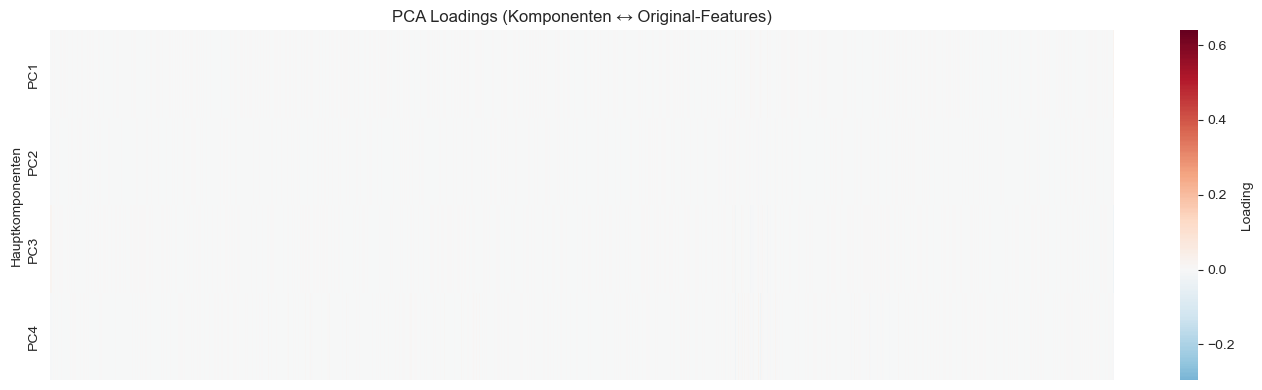

In [20]:
# === Notebook-Block: Welche Original-Features fließen in die PCA? ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Daten laden
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv'
df = pd.read_csv(input_csv, dtype=str)

# 2) Wie beim Training alle Spalten droppen, die nicht in X_enc gehören
drop_cols = [
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b',
    # Hier ergänzen, damit die PCA-Komponenten-Matrix wieder passt:
    'ml_pred_global','ml_pred_pipeline'
]
X_raw = df.drop(columns=drop_cols)

# One-hot und Konstanten wie im Training entfernen
X_enc = pd.get_dummies(X_raw, drop_first=True)
consts = X_enc.columns[X_enc.nunique() <= 1]
X_enc = X_enc.drop(columns=consts)

# 3) Hol dir die PCA-Instanz aus deinem besten Modell
best_pipe = bayes.best_estimator_
pca = best_pipe.named_steps['pca']

if pca == 'passthrough':
    print("PCA wurde übersprungen; alle Features:")
    print(list(X_enc.columns))
else:
    # 4) Lade die Komponenten-Matrix in ein DataFrame
    comp = pca.components_  # shape (n_components, n_features)
    n_pc, n_feat = comp.shape
    feat_names = X_enc.columns.to_list()
    
    loadings = pd.DataFrame(
        comp,
        index=[f"PC{i+1}" for i in range(n_pc)],
        columns=feat_names
    )

    # 5) Top-10 Loadings je Komponente
    for pc in loadings.index:
        print(f"\nTop-10 Loadings für {pc}:")
        display(loadings.loc[pc]
                    .abs()
                    .sort_values(ascending=False)
                    .head(10)
                    .to_frame(name="|Loading|"))

    # 6) Heatmap aller Loadings
    plt.figure(figsize=(14, max(4, n_pc*0.5)))
    sns.heatmap(
        loadings,
        cmap="RdBu_r",
        center=0,
        cbar_kws={'label': 'Loading'},
        xticklabels=False  # oder True, wenn Platz da ist
    )
    plt.ylabel("Hauptkomponenten")
    plt.title("PCA Loadings (Komponenten ↔ Original-Features)")
    plt.tight_layout()
    plt.show()


In [17]:
# 1) Lade die Datei und zeige alle Spalten
import pandas as pd

df = pd.read_csv(r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv', dtype=str)
print("Alle Spalten im DataFrame:")
for col in df.columns:
    print(" -", col)


Alle Spalten im DataFrame:
 - feature_count
 - selection_method
 - reducer
 - n_components
 - outlier_method
 - scaler_method
 - use_sex
 - trail_a_id
 - trail_b_id
 - samples_a
 - samples_b
 - ind_a
 - ind_b
 - same_individual
 - fold
 - pipeline
 - k_features
 - comparison_id
 - min_observations
 - max_observations
 - use_sexmodel_prediction
 - center_a_x
 - center_a_y
 - center_b_x
 - center_b_y
 - center_r_x
 - center_r_y
 - coords_a_x
 - coords_a_y
 - coords_b_x
 - coords_b_y
 - coords_r_x
 - coords_r_y
 - dist_euclidean
 - mean_euclidean_between
 - median_euclidean_between
 - mean_euclidean_within_a
 - median_euclidean_within_a
 - mean_euclidean_within_b
 - median_euclidean_within_b
 - dist_manhattan
 - mean_manhattan_between
 - median_manhattan_between
 - mean_manhattan_within_a
 - median_manhattan_within_a
 - mean_manhattan_within_b
 - median_manhattan_within_b
 - dist_cosine
 - mean_cosine_between
 - median_cosine_between
 - mean_cosine_within_a
 - median_cosine_within_a
 - me

In [12]:
# === Notebook-Block: Modelle fitten & Vorhersagen speichern ===

import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from scipy.stats import randint

# 1) Daten laden & vorbereiten
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_exact_jmp_overlap_parallel.csv'
df = pd.read_csv(input_csv, dtype=str)
df['same_individual'] = df['same_individual'].map({'True':1,'False':0}).astype(int)
df['fold']            = df['fold'].astype(float).astype(int)

# Imputation avg_proba_*
for col in ['avg_proba_A_0','avg_proba_B_0']:
    valid = df[df[col].notna()]
    fill_map = (valid.groupby('comparison_id')[col]
                    .agg(lambda s: s.unique()[0] if len(s.unique())==1 else np.nan)
                    .dropna().to_dict())
    df[col] = df.apply(lambda r: fill_map.get(r['comparison_id'], r[col]), axis=1)

# 2) Feature-Engineering
drop_cols = [
    'same_individual','pipeline','fold',
    'trail_a_id','trail_b_id','samples_a','samples_b',
    'ind_a','ind_b',
    'coords_a_x','coords_a_y','coords_b_x','coords_b_y','coords_r_x','coords_r_y',
    'mean_mahalanobis_between','median_mahalanobis_between',
    'mean_mahalanobis_within_a','median_mahalanobis_within_a',
    'mean_mahalanobis_within_b','median_mahalanobis_within_b'
]
X_raw = df.drop(columns=drop_cols)
y     = df['same_individual']
groups= df['fold']

X_enc = pd.get_dummies(X_raw, drop_first=True)
consts = X_enc.columns[X_enc.nunique() <= 1]
X_enc.drop(columns=consts, inplace=True)

# 3) Randomized Search Config
param_dist = {
    'pca': ['passthrough'] + [PCA(n_components=i) for i in range(1,6)],
    'select__k': [1,2,3,5,10, X_enc.shape[1]],
    'clf': [
        RandomForestClassifier(n_estimators=50,  random_state=42),
        RandomForestClassifier(n_estimators=200, random_state=42),
        ExtraTreesClassifier(n_estimators=100, random_state=42),
        XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
        SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
    ]
}

def fit_model(X, y, groups, n_splits, n_iter=5):
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca', PCA()),
        ('select', SelectKBest(f_classif)),
        ('clf', RandomForestClassifier())
    ])
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=make_scorer(balanced_accuracy_score),
        cv=GroupKFold(n_splits=n_splits),
        n_jobs=-1,
        refit=True,
        random_state=42,
        verbose=0
    )
    rs.fit(X, y, groups=groups)
    return rs.best_estimator_

# 4) Globales Modell trainieren
global_model = fit_model(X_enc, y, groups, n_splits=groups.nunique(), n_iter=10)
df['ml_pred_global'] = global_model.predict(X_enc)

# 5) Pipeline-spezifische Modelle trainieren
df['ml_pred_pipeline'] = np.nan
for p in df['pipeline'].unique():
    mask = df['pipeline'] == p
    X_sub = X_enc.loc[mask]
    y_sub = y.loc[mask]
    groups_sub = groups.loc[mask]
    if X_sub.shape[0] < 10:
        df.loc[mask, 'ml_pred_pipeline'] = 0
    else:
        model_p = fit_model(X_sub, y_sub, groups_sub, n_splits=3, n_iter=5)
        df.loc[mask, 'ml_pred_pipeline'] = model_p.predict(X_sub)

df['ml_pred_pipeline'] = df['ml_pred_pipeline'].astype(int)

# 6) Ergebnisse speichern
output_with_preds = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv'
df.to_csv(output_with_preds, index=False)
print(f"Vorhersagen gespeichert in: {output_with_preds}")



c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:07:42] WARNING: D:\bld\xgboost-split_1748292851775\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46767 46768 46769] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 46767 46768 46769] are constant.
  warnings.warn("Features %s are con

Vorhersagen gespeichert in: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv


             method       TPR       TNR  Accuracy  Balanced_Acc  Harmonic_Mean
0   ellipse_overlap  0.600000  0.837500  0.705556      0.718750       0.699130
1    ml_pred_global  1.000000  1.000000  1.000000      1.000000       1.000000
2  ml_pred_pipeline  0.691429  0.823214  0.750000      0.757321       0.751588


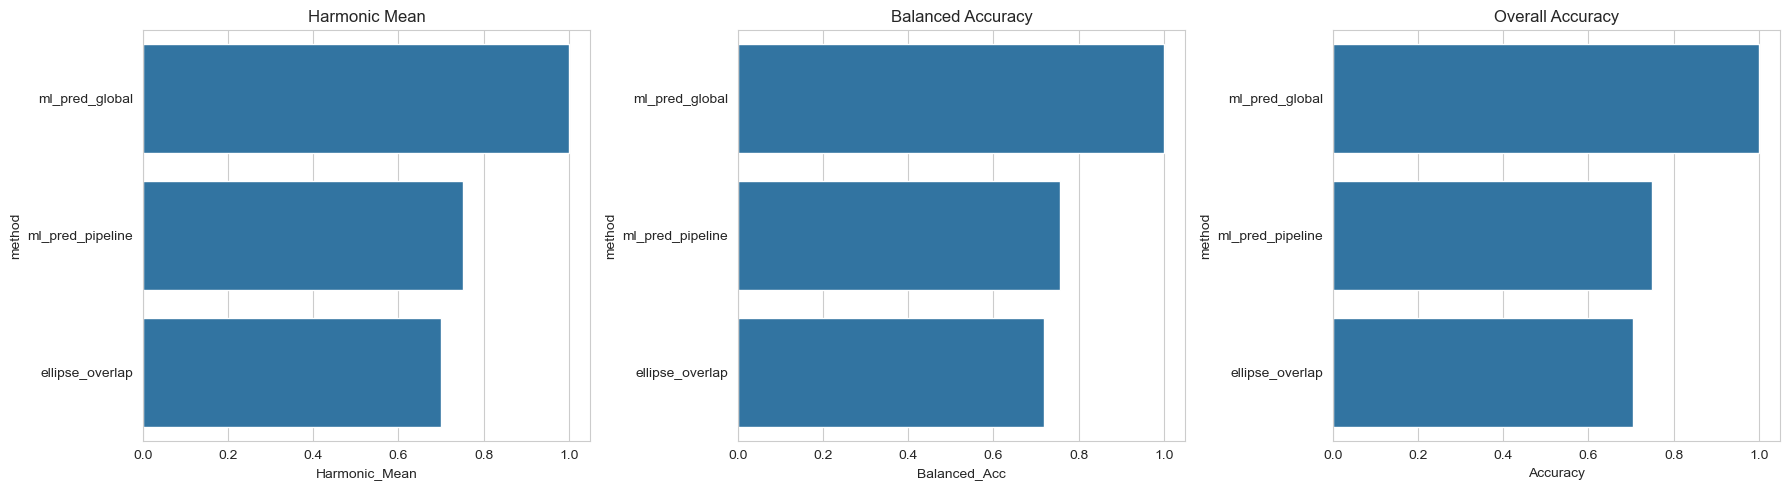

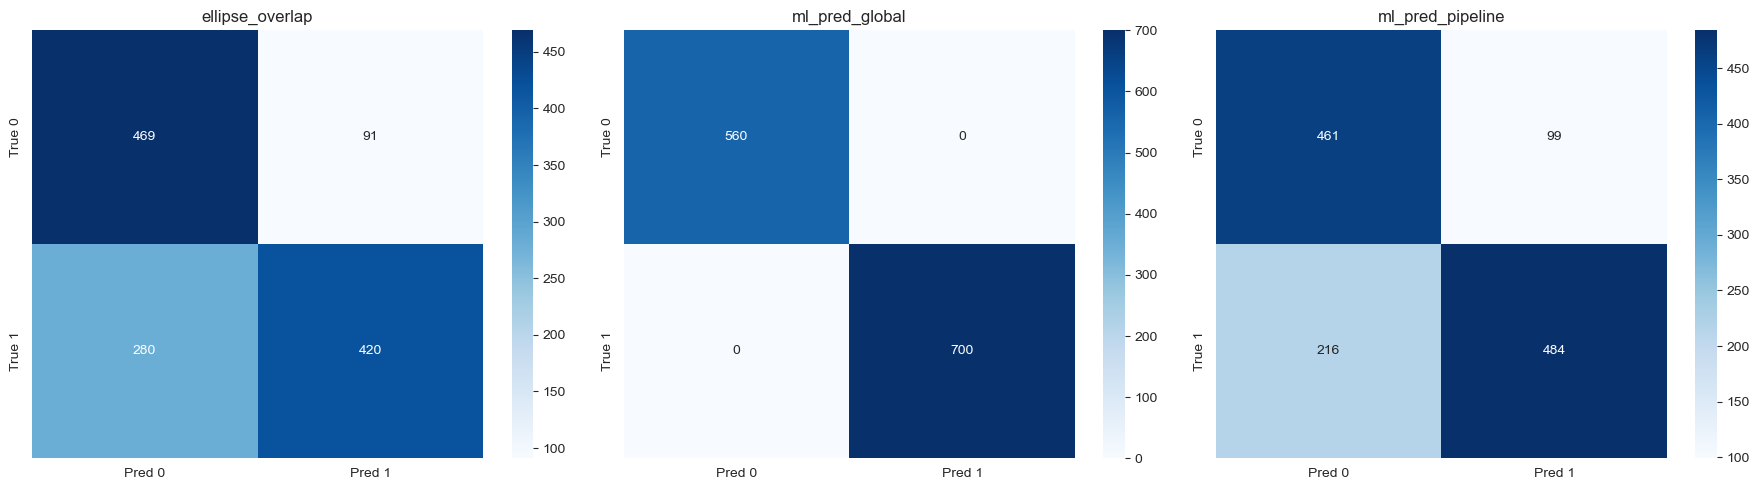

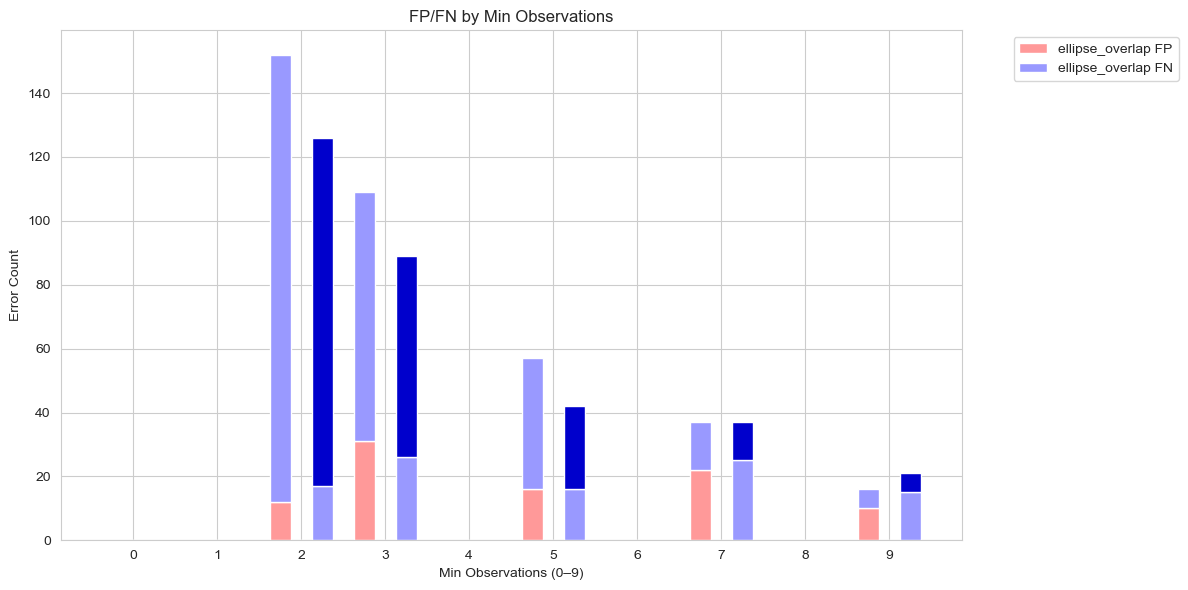

In [16]:
# === Notebook-Block: Vergleich Radius vs. Global-ML vs. Pipeline-ML ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# 1) Daten laden (mit Vorhersagen in 'ml_pred_global' & 'ml_pred_pipeline')
input_csv = r'C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pairwise_comp_all_species_experiment\results_with_preds.csv'
df = pd.read_csv(input_csv, dtype=str)

# 2) Spalten in numerisch umwandeln – Karten für '0','1','True','False'
map01 = {'True':1,'False':0,'1':1,'0':0}
df['same_individual']      = df['same_individual'].map(map01)
df['ellipse_overlap']      = df['ellipse_overlap'].map(map01)
df['ml_pred_global']       = df['ml_pred_global'].map(map01)
df['ml_pred_pipeline']     = df['ml_pred_pipeline'].map(map01)

# 3) Kennzahlen für Radius- vs. Global-ML vs. Pipeline-ML berechnen
methods = ['ellipse_overlap', 'ml_pred_global', 'ml_pred_pipeline']
metrics = []
for m in methods:
    y_true = df['same_individual']
    y_pred = df[m]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = recall_score(y_true, y_pred)
    tnr = tn / (tn + fp) if (tn + fp)>0 else np.nan
    acc = accuracy_score(y_true, y_pred)
    bal = (tpr + tnr) / 2
    hm  = 2*(tpr*tnr)/(tpr+tnr) if (tpr+tnr)>0 else np.nan
    metrics.append({
        'method':        m,
        'TPR':           tpr,
        'TNR':           tnr,
        'Accuracy':      acc,
        'Balanced_Acc':  bal,
        'Harmonic_Mean': hm
    })
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# 4) Balkendiagramme für HM, Balanced Accuracy & Overall Accuracy
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(x='Harmonic_Mean', y='method',
            data=metrics_df.sort_values('Harmonic_Mean', ascending=False),
            ax=axes[0])
axes[0].set_title("Harmonic Mean")

sns.barplot(x='Balanced_Acc', y='method',
            data=metrics_df.sort_values('Balanced_Acc', ascending=False),
            ax=axes[1])
axes[1].set_title("Balanced Accuracy")

sns.barplot(x='Accuracy', y='method',
            data=metrics_df.sort_values('Accuracy', ascending=False),
            ax=axes[2])
axes[2].set_title("Overall Accuracy")

plt.tight_layout()
plt.show()

# 5) Confusion-Matrices nebeneinander
fig, axes = plt.subplots(1, len(methods), figsize=(6*len(methods),5))
for ax, m in zip(axes, methods):
    cm = confusion_matrix(df['same_individual'], df[m])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(m)
plt.tight_layout()
plt.show()

# 6) Fehler-Typ (FP/FN) nach Min Observations
df['min_observations'] = df['min_observations'].astype(float).round().astype(int)

# Error-Spalten anlegen
for m in methods:
    df[f'error_{m}'] = np.where(
        (df['same_individual']==0) & (df[m]==1), 'FP',
        np.where((df['same_individual']==1) & (df[m]==0), 'FN', 'OK')
    )

# Stacked-Bar-Plot für alle drei Ansätze
plt.figure(figsize=(12,6))
x = np.arange(10)
width = 0.25
offsets = [-width, 0, width]

colors = {
    'ellipse_overlap':   {'FP':'#ff9999','FN':'#9999ff'},
    'ml_pred_global':    {'FP':'#99ff99','FN':'#009900'},
    'ml_pred_pipeline':  {'FP':'#9999ff','FN':'#0000cc'}
}

bottom_template = np.zeros_like(x, dtype=float)

for i, m in enumerate(methods):
    err_col = f'error_{m}'
    raw_ct = (
        df[df[err_col].isin(['FP','FN'])]
        .groupby(['min_observations', err_col])
        .size()
        .unstack(fill_value=0)
    )
    ct = raw_ct.reindex(index=x, columns=['FP','FN'], fill_value=0)
    bottom = bottom_template.copy()
    xpos = x + offsets[i]
    for et in ['FP','FN']:
        plt.bar(xpos, ct[et], width=width, bottom=bottom,
                color=colors[m][et],
                label=f"{m} {et}" if i==0 else "")
        bottom += ct[et].values

plt.xticks(x, x)
plt.xlabel("Min Observations (0–9)")
plt.ylabel("Error Count")
plt.title("FP/FN by Min Observations")
handles, labels = plt.gca().get_legend_handles_labels()
by_lbl = dict(zip(labels, handles))
plt.legend(by_lbl.values(), by_lbl.keys(), bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
